In [1]:
import uproot as ur
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import mplhep as hep
hep.style.use("CMS")

plt.rcParams['figure.facecolor']='white'
plt.rcParams['savefig.facecolor']='white'
plt.rcParams['savefig.bbox']='tight'
plt.rcParams['legend.frameon']=True
plt.rcParams['legend.edgecolor']='white'
import uproot#glob,ROOT

from scipy.optimize import curve_fit

plt.rcParams["figure.figsize"] = (10, 8)

import gc

In [2]:
from io import StringIO
import pandas as pd
calc_str = StringIO("""nu,nb_D0,nb_D0star
    8.75,7.5,0
    8.85,12.9,0
    8.95,17.0,0
    9.05,19.7,0
    9.15,21.8,0
    9.25,23.8,0
    9.35,25.2,0
    9.45,26.5,21.8
    9.55,27.2,30.6
    9.65,28.2,36.4
    9.75,29.3,40.8
    9.85,29.9,44.9
    9.95,30.6,47.6
    10.05,31.3,50.3
    """)

calc = pd.read_csv(calc_str, sep=",")

calc_str = StringIO("""nu,nb_D0,nb_D0star
    8.714, 0,0
    8.72,3.4,0
    8.73,4.76,0
    8.75,7.5,0
    8.85,12.9,0
    8.95,17.0,0
    9.05,19.7,0
    9.15,21.8,0
    9.25,23.8,0
    9.35,25.2,0
    9.362,25.3,6.8
    9.41,25.9,16.3
    9.45,26.5,21.8
    9.55,27.2,30.6
    9.65,28.2,36.4
    9.75,29.3,40.8
    9.85,29.9,44.9
    9.95,30.6,47.6
    10.05,31.3,50.3
    """)

9354.4,0.0
9381.2,11.6
9385.1,25.9
9408.0,16.3
9408.0,25.9
9431.0,19.7
9431.0,25.9
9362.1,6.8
9362.1,25.2

calc_smooth = pd.read_csv(calc_str, sep=",")


In [3]:
8.76,0.81
8.85,0.90
8.95,0.90
9.05,0.90
9.15,0.90
9.25,0.90
9.35,0.84
9.45,0.78
9.55,0.71
9.65,0.59
9.75,0.48
9.85,0.33
9.95,0.24
10.05,0.12



eff=np.array([0.81, 0.9,0.9,0.9,0.9, 0.9, 0.84, 0.78, 0.71, 0.59, 0.48, 0.33, 0.24, 0.12])

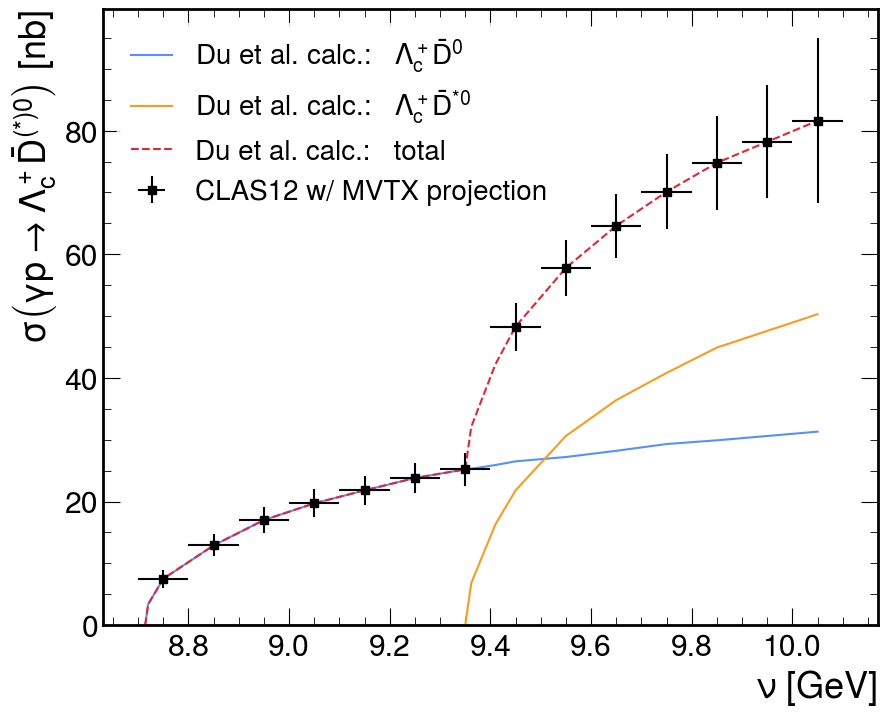

In [4]:
plt.plot(calc_smooth.nu, calc_smooth.nb_D0, label="Du et al. calc.:   $\\Lambda_c^+ \\bar D^0$ ")
plt.plot(calc_smooth.nu, calc_smooth.nb_D0star, label="Du et al. calc.:   $\\Lambda_c^+ \\bar D^{*0}$")
plt.plot(calc_smooth.nu, calc_smooth.nb_D0+calc_smooth.nb_D0star, label="Du et al. calc.:   total", ls='--')

s=calc.nb_D0+calc.nb_D0star
y=calc.nu/10.6
f=(1-y+y**2/2)/y
#N=12000*s*eff*f/sum(s*eff*f)
N=1300*s*eff*f/sum(s*eff*f)
ds=s/np.sqrt(N)
plt.errorbar(calc.nu, s, ds, 0.05, color='k', label="CLAS12 w/ MVTX projection", marker='s', ls='')
plt.ylim(0)
plt.xlabel("$\\nu$ [GeV]")
plt.ylabel("$\\sigma\\left(\\gamma p\\rightarrow \\Lambda_c^+\\bar D^{(*)0}\\right)$ [nb]")
plt.legend(fontsize=20)
plt.savefig("images/reach.pdf")

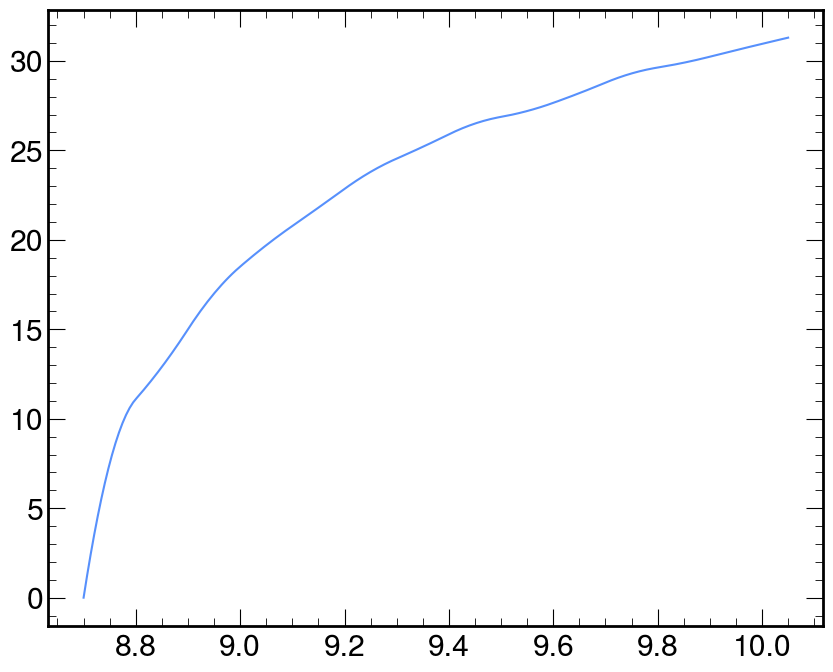

In [5]:
from scipy.interpolate import make_interp_spline, BSpline

#create data
x = np.concatenate([[8.7], calc.nu])
y = np.concatenate([[0], calc.nb_D0])

#define x as 200 equally spaced values between the min and max of original x 
xnew = np.linspace(x.min(), x.max(), 200) 

#define spline
spl = make_interp_spline(x, y, k=2)

plt.plot(xnew, spl(xnew), label="Du et al. calc $D^0$ ")

In [6]:
8756.7,7.5
8848.7,12.9
8948.3,17.0
9051.7,19.7
9151.3,21.8
9251.0,23.8
9350.6,25.2
9450.2,26.5
9549.8,27.2
9637.9,27.9
9741.4,29.3
9848.7,29.9
9948.3,31.0
10051.7,30.6
9450.2,21.8
9549.8,30.6
9637.9,35.4
9749.0,40.8
9852.5,44.9
9948.3,47.6
10051.7,50.3
9354.4,0.0


(9354.4, 0.0)

{'marker': 's', 'ls': '', 'color': 'tab:blue'}
{'marker': 'o', 'ls': '', 'color': 'tab:orange'}
{'marker': 's', 'ls': '', 'color': 'k', 'fillstyle': 'none'}


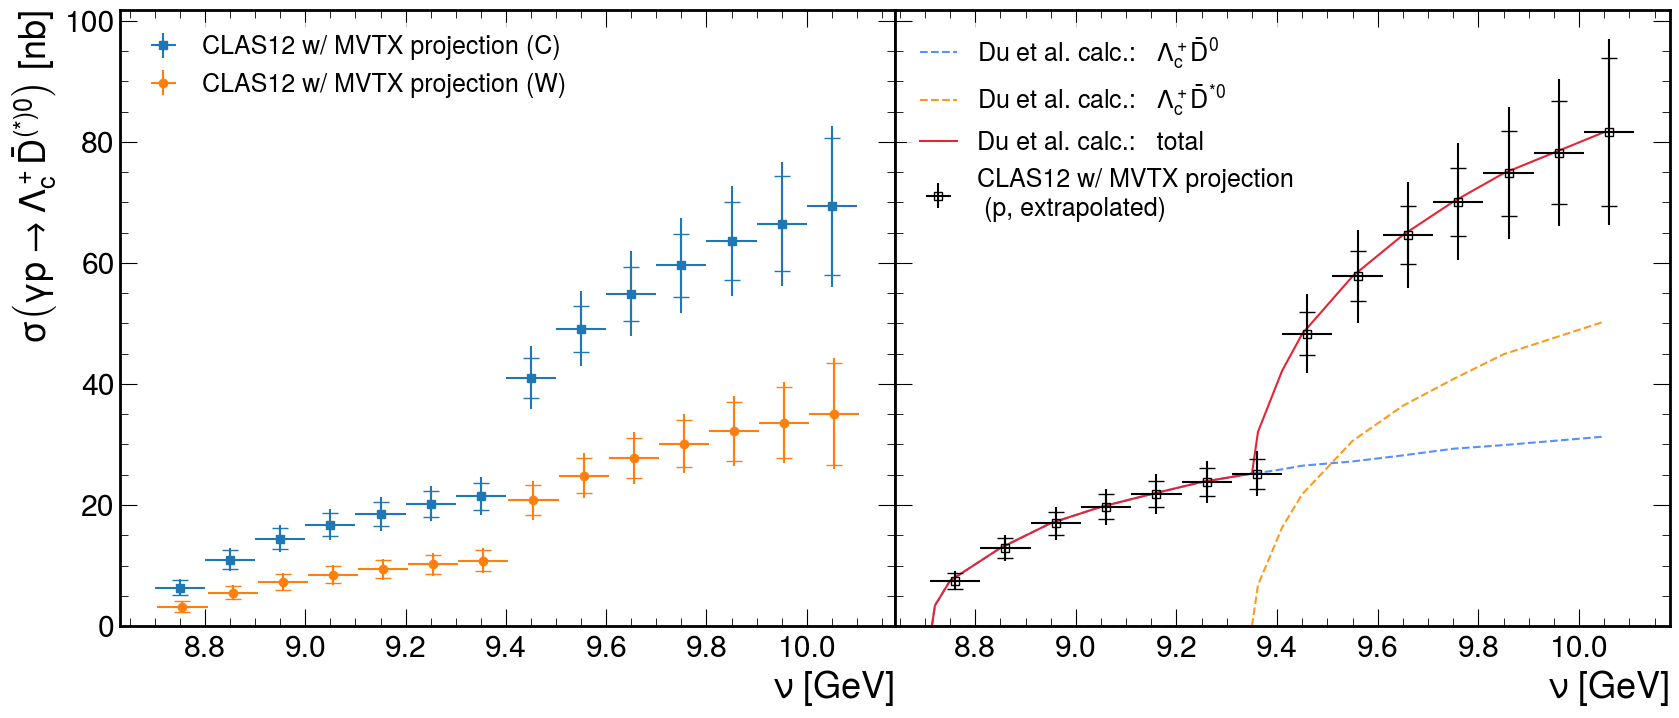

In [8]:
fig,axs=plt.subplots(1,2, figsize=(20,8), sharey='all')

axs[1].plot(calc_smooth.nu, calc_smooth.nb_D0, label="Du et al. calc.:   $\\Lambda_c^+ \\bar D^0$ ", ls='--')
axs[1].plot(calc_smooth.nu, calc_smooth.nb_D0star, label="Du et al. calc.:   $\\Lambda_c^+ \\bar D^{*0}$", ls='--')
axs[1].plot(calc_smooth.nu, calc_smooth.nb_D0+calc_smooth.nb_D0star, label="Du et al. calc.:   total", ls='-')

s=calc.nb_D0+calc.nb_D0star
y=calc.nu/10.6
f=(1-y+y**2/2)/y

styles=[dict(marker='s', ls='',color='tab:blue'),dict(marker='o', ls='',color='tab:orange'), dict(marker='s', ls='',color='k',fillstyle='none')] 
for i,(shadow, Ntot) in enumerate(((0.85, 1300), (0.43, 600), (1, 1300/0.85))):
    if i !=2:
        plt.sca(axs[0])
    else:
        plt.sca(axs[1])
    target='C;W;p, extrapolated'.split(';')[i]
    N=Ntot*s*eff*f/sum(s*eff*f)
    ds=s/np.sqrt(N)
    print(styles[i])
    syst=.10 if i!=2 else np.hypot(.10,.05)
    br='' if i!=2 else '\n'
    plt.errorbar(calc.nu+.005*i, shadow*s, np.hypot(shadow*ds, shadow*s*syst), 0.05, label=f"CLAS12 w/ MVTX projection{br} ({target})", **(styles[i]))
    a=styles[i].copy()
    #
    a['marker']=''
    a['capsize']=6
    plt.errorbar(calc.nu+.005*i, shadow*s, shadow*ds, **a)
    
axs[0].set_ylim(0)
axs[0].set_xlabel("$\\nu$ [GeV]")
axs[1].set_xlabel("$\\nu$ [GeV]")
axs[0].set_ylabel("$\\sigma\\left(\\gamma p\\rightarrow \\Lambda_c^+\\bar D^{(*)0}\\right)$ [nb]")
axs[0].legend(fontsize=18, loc='upper left')
axs[1].legend(fontsize=18)
plt.subplots_adjust(wspace=0)
plt.savefig("images/reach.pdf")

0      21.126420
1      39.794603
2      51.703796
3      59.088764
4      64.503887
5      69.489955
6      67.783263
7     119.110018
8     128.138582
9     117.567723
10    102.563962
11     74.371157
12     55.908956
13     28.848914
dtype: float64
{'marker': 's', 'ls': '', 'color': 'tab:blue'}
0      8.873096
1     16.713733
2     21.715594
3     24.817281
4     27.091632
5     29.185781
6     28.468970
7     50.026207
8     53.818204
9     49.378444
10    43.076864
11    31.235886
12    23.481761
13    12.116544
dtype: float64
{'marker': 'o', 'ls': '', 'color': 'tab:orange'}


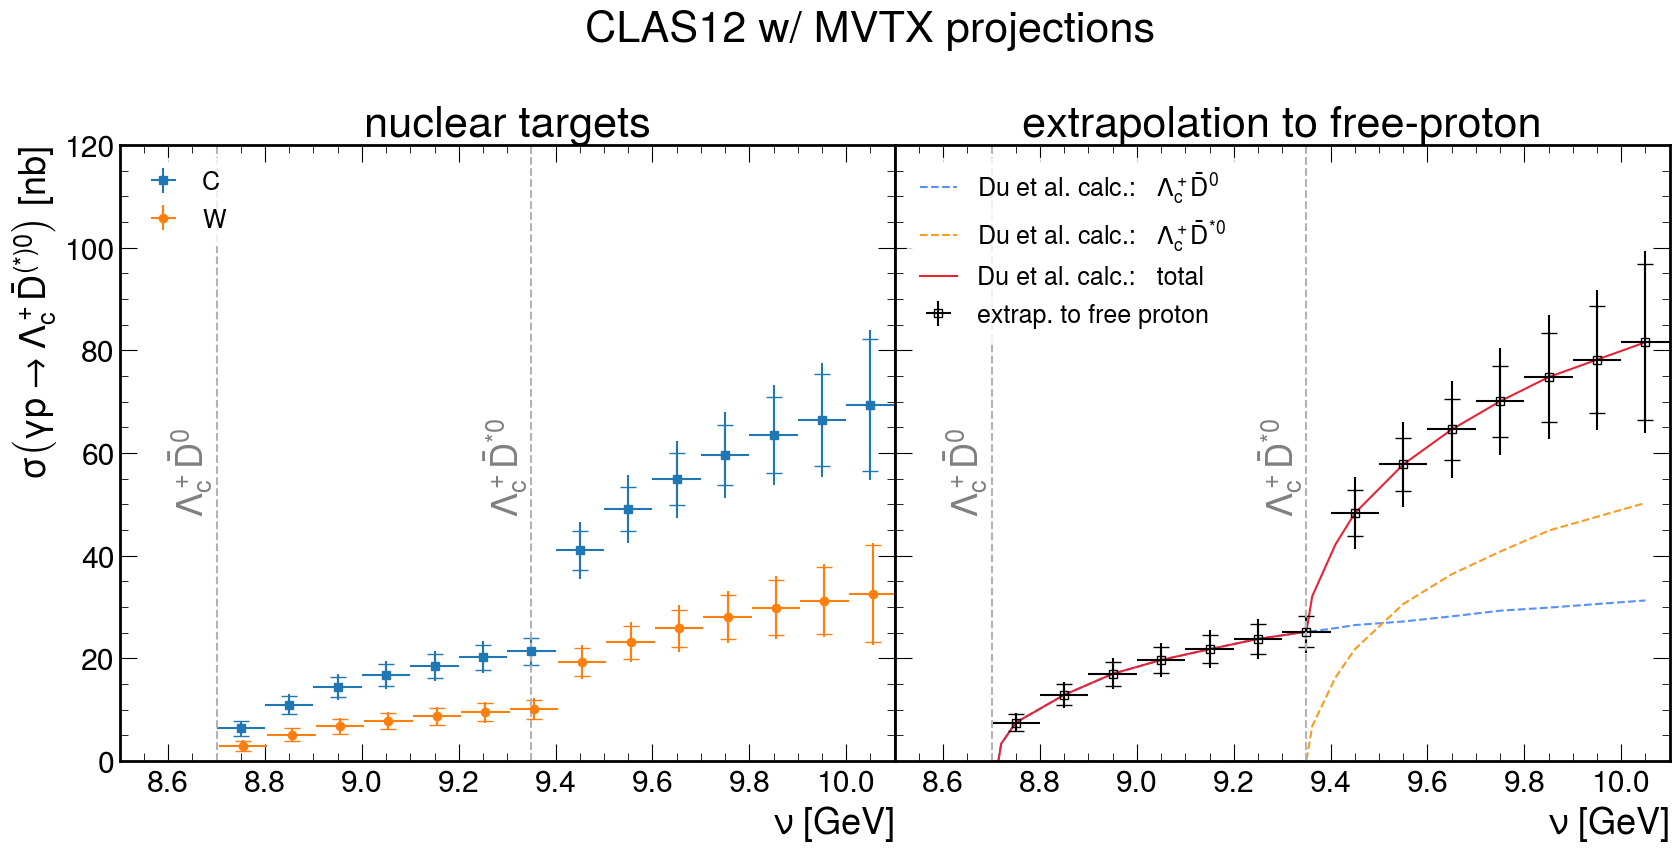

[ 23  39  54  49  63  64  84 117 122 107 104  79  47  30]
{'marker': 's', 'ls': '', 'color': 'tab:blue'}
[12 22 24 26 32 24 37 49 45 60 43 31 24  8]
{'marker': 'o', 'ls': '', 'color': 'tab:orange'}


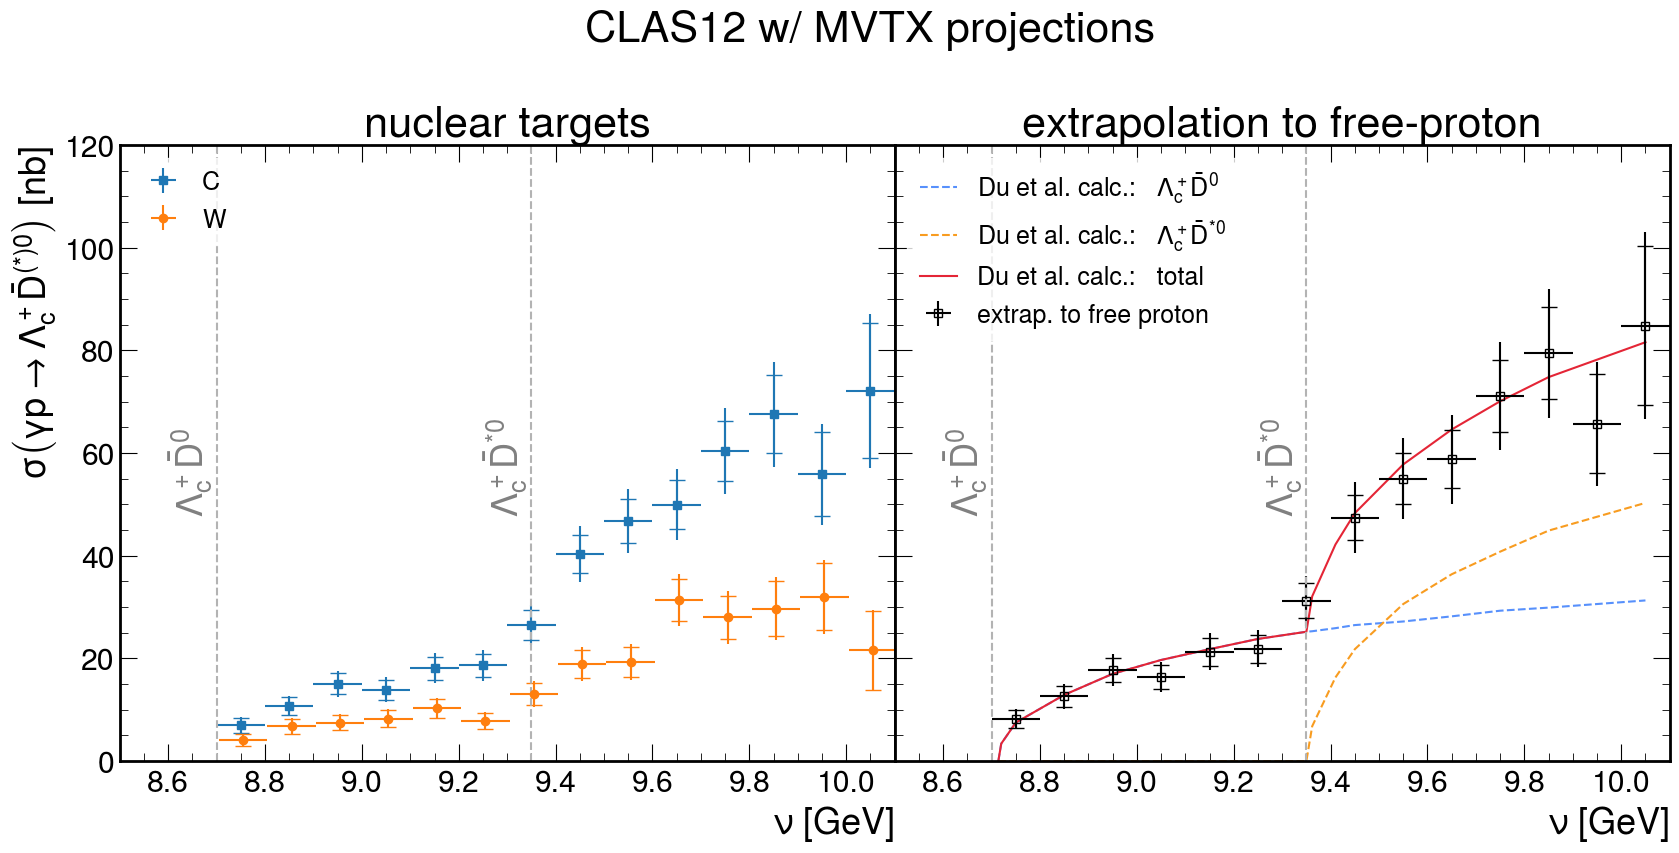

In [9]:
for raffled in False, True:
    fig,axs=plt.subplots(1,2, figsize=(20,8), sharey='all', sharex='all')
    
    axs[1].plot(calc_smooth.nu, calc_smooth.nb_D0, label="Du et al. calc.:   $\\Lambda_c^+ \\bar D^0$ ", ls='--')
    axs[1].plot(calc_smooth.nu, calc_smooth.nb_D0star, label="Du et al. calc.:   $\\Lambda_c^+ \\bar D^{*0}$", ls='--')
    axs[1].plot(calc_smooth.nu, calc_smooth.nb_D0+calc_smooth.nb_D0star, label="Du et al. calc.:   total", ls='-')
    
    s=calc.nb_D0+calc.nb_D0star
    y=calc.nu/10.6
    f=(1-y+y**2/2)/y
    
    styles=[dict(marker='s', ls='',color='tab:blue'),dict(marker='o', ls='',color='tab:orange'), dict(marker='s', ls='',color='k',fillstyle='none')] 
    for i,(shadow, Ntot) in enumerate(((0.85, 1000), (0.40, 420))):
        plt.sca(axs[0])
        target='C;W;p, extrapolated'.split(';')[i]
        N=Ntot*s*eff*f/sum(s*eff*f)
    
        if raffled:
            Nsmear=np.random.poisson(N)
            s1=s*Nsmear/N
            N=Nsmear
        else:
            s1=s
        print(N)
        ds=s1/np.sqrt(N)
        print(styles[i])
        syst=.10
        br='' if i!=2 else '\n'
        plt.errorbar(calc.nu+.005*i, shadow*s1, np.hypot(shadow*ds, shadow*s1*syst), 0.05, label=target, **(styles[i]))
        a=styles[i].copy()
        #
        a['marker']=''
        a['capsize']=6
        plt.errorbar(calc.nu+.005*i, shadow*s1, shadow*ds, **a)
    
        if i ==0:
            plt.sca(axs[1])
            syst=np.hypot(.10,.05)
            br='' if i!=2 else '\n'
            plt.errorbar(calc.nu+.005*i, s1, np.hypot(ds, s1*syst), 0.05, label="extrap. to free proton", **(styles[2]))
            a=styles[2].copy()
            #
            a['marker']=''
            a['capsize']=6
            plt.errorbar(calc.nu+.005*i, s1, ds, **a)
    
        
    axs[0].set_ylim(0, 120)
    axs[0].set_xlabel("$\\nu$ [GeV]")
    axs[1].set_xlabel("$\\nu$ [GeV]")
    axs[0].set_ylabel("$\\sigma\\left(\\gamma p\\rightarrow \\Lambda_c^+\\bar D^{(*)0}\\right)$ [nb]")
    axs[0].legend(fontsize=18, loc='upper left')
    axs[1].legend(fontsize=18)

    axs[0].set_title("nuclear targets")
    axs[1].set_title("extrapolation to free-proton")
    
    
    for ax in axs:
        plt.sca(ax)
        ax.set_xlim(8.5, 10.1)
        for i in 0,1:
            thr=[8.7,9.35][i]
            ax.axvline(thr, ls='--', color='0.7')
            txt='$\\Lambda_c^+\\bar D^0$' if i ==0 else '$\\Lambda_c^+\\bar D^{*0}$'
            ax.text(thr-.1, 50, txt, rotation=90, color='0.5')
    fig.suptitle("CLAS12 w/ MVTX projections", y=1.05)
    plt.subplots_adjust(wspace=0)
    if raffled==False:
        plt.savefig("images/reach.pdf")
    if raffled==True:
        plt.savefig("images/reach_rand.pdf")
    plt.show()

In [81]:
help(np.random.poisson)

Help on method poisson in module numpy.random:

poisson(lam=1.0, size=None) method of numpy.random.mtrand.RandomState instance
    poisson(lam=1.0, size=None)
    
    Draw samples from a Poisson distribution.
    
    The Poisson distribution is the limit of the binomial distribution
    for large N.
    
    .. note::
        New code should use the `~numpy.random.Generator.poisson`
        method of a `~numpy.random.Generator` instance instead;
        please see the :ref:`random-quick-start`.
    
    Parameters
    ----------
    lam : float or array_like of floats
        Expected number of events occurring in a fixed-time interval,
        must be >= 0. A sequence must be broadcastable over the requested
        size.
    size : int or tuple of ints, optional
        Output shape.  If the given shape is, e.g., ``(m, n, k)``, then
        ``m * n * k`` samples are drawn.  If size is ``None`` (default),
        a single value is returned if ``lam`` is a scalar. Otherwise,
        